In [2]:
pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install opencv-python pandas matplotlib 

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 6.2 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install kaggle 

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import os

!kaggle datasets download -d jonathanoheix/face-expression-recognition-dataset \
     --unzip


/Users/fokia/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset
License(s): unknown
face-expression-recognition-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [11]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 6.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 6.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
## TRAINING TIME 
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models , Model 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [18]:
BASE_DIR = "/Users/fokia/CentraleSupelec-CV-and-RL-project/data/images"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

IMG_SIZE   = (48, 48)   # FER images are grayscale 48x48
BATCH_SIZE = 64
EPOCHS     = 50
NUM_CLASSES = 7

classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


TypeError: 'int' object is not iterable

In [16]:
def build_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model = build_model()
model.summary()


/Users/fokia/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,469,923 (5.61 MB)

 Trainable params: 1,468,515 (5.60 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_model.keras", save_best_only=True, verbose=1)
]


In [17]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50


/Users/fokia/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.2327 - loss: 2.2975
Epoch 1: val_loss improved from inf to 1.67250, saving model to best_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - accuracy: 0.2328 - loss: 2.2968 - val_accuracy: 0.3290 - val_loss: 1.6725 - learning_rate: 0.0010
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.3739 - loss: 1.6211
Epoch 2: val_loss improved from 1.67250 to 1.37014, saving model to best_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 57s 127ms/step - accuracy: 0.3739 - loss: 1.6210 - val_accuracy: 0.4776 - val_loss: 1.3701 - learning_rate: 0.0010
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4575 - loss: 1.4121
Epoch 3: val_loss improved from 1.37014 to 1.21007, saving model to best_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 59s 131ms/step - accuracy: 0.4575 - loss: 1.4121 - val_accuracy: 0.5382 - val_loss: 1.2101 - learning_rate: 0.0010
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy

In [36]:
# ITERATION TWO : 
BASE_DIR  = "/Users/fokia/CentraleSupelec-CV-and-RL-project/data/images"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "validation")

IMG_SIZE   = 48
BATCH_SIZE = 64
EPOCHS     = 50
NUM_CLASSES = 6

# Map original folder name → new class index (None = exclude)
LABEL_MAP = {
    "angry":   0,    # alert
    "disgust": 1,    # negative
    "fear":    2,    # negative
    "happy":   3,    # alert
    "neutral": 4,    # neutral
    "sad":     1,    # negative
    "surprise":5,    # alert
}

CLASS_NAMES = ["angry","sad","fear", "happy", "neutral", "surprise"]
 

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, NUM_CLASSES)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_dataset(directory, label_map, augment_data=False):
    paths, labels = [], []
    for emotion in sorted(os.listdir(directory)):
        new_label = label_map.get(emotion)
        if new_label is None:
            continue
        folder = os.path.join(directory, emotion)
        if not os.path.isdir(folder):
            continue
        for fname in os.listdir(folder):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(folder, fname))
                labels.append(new_label)

    print(f"  Loaded {len(paths)} images from {directory}")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds, len(paths)

print("Building datasets...")
train_ds, n_train = make_dataset(TRAIN_DIR, LABEL_MAP, augment_data=True)
val_ds,   n_val   = make_dataset(VAL_DIR,   LABEL_MAP, augment_data=False)
print(f"Train: {n_train} | Val: {n_val}")


Building datasets...
  Loaded 28821 images from /Users/fokia/CentraleSupelec-CV-and-RL-project/data/images/train
  Loaded 7066 images from /Users/fokia/CentraleSupelec-CV-and-RL-project/data/images/validation
Train: 28821 | Val: 7066


Train distribution: {'happy': 7164, 'sad': 5374, 'fear': 4103, 'surprise': 3205, 'neutral': 4982, 'angry': 3993}


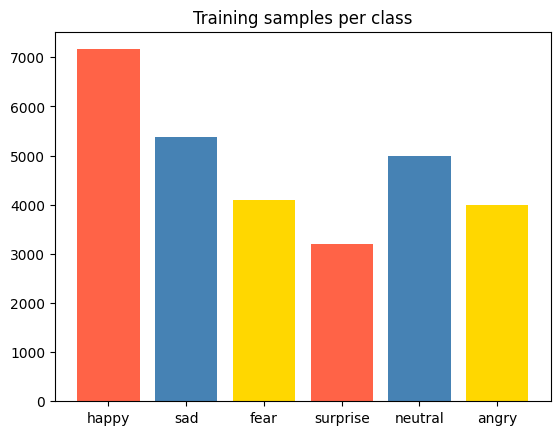

In [37]:
from collections import defaultdict

def class_counts(directory, label_map):
    counts = defaultdict(int)
    for emotion in os.listdir(directory):
        new_label = label_map.get(emotion)
        if new_label is None:
            continue
        folder = os.path.join(directory, emotion)
        if os.path.isdir(folder):
            counts[CLASS_NAMES[new_label]] += len(os.listdir(folder))
    return dict(counts)

train_counts = class_counts(TRAIN_DIR, LABEL_MAP)
print("Train distribution:", train_counts)

plt.bar(train_counts.keys(), train_counts.values(), color=['tomato','steelblue','gold'])
plt.title("Training samples per class"); plt.show()


In [ ]:
class STN(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.loc_conv1 = tf.keras.layers.Conv2D(32, 5, padding='same', activation='relu')
        self.loc_pool1 = tf.keras.layers.MaxPooling2D(2)
        self.loc_conv2 = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')
        self.loc_pool2 = tf.keras.layers.MaxPooling2D(2)
        self.loc_flatten = tf.keras.layers.Flatten()
        self.loc_fc1 = tf.keras.layers.Dense(128, activation='relu')
        self.loc_fc2 = tf.keras.layers.Dense(
            6,
            kernel_initializer='zeros',
            bias_initializer=tf.keras.initializers.Constant([1, 0, 0, 0, 1, 0])
        )
        super().build(input_shape)

    def call(self, x):
        B = tf.shape(x)[0]
        H, W = x.shape[1], x.shape[2]

        # Localisation network
        loc = self.loc_conv1(x)
        loc = self.loc_pool1(loc)
        loc = self.loc_conv2(loc)
        loc = self.loc_pool2(loc)
        loc = self.loc_flatten(loc)
        loc = self.loc_fc1(loc)
        theta = self.loc_fc2(loc)                          # (B, 6)
        theta = tf.reshape(theta, [B, 2, 3])               # (B, 2, 3)

        # Affine grid
        x_lin = tf.linspace(-1.0, 1.0, W)
        y_lin = tf.linspace(-1.0, 1.0, H)
        xg, yg = tf.meshgrid(x_lin, y_lin)
        ones = tf.ones_like(xg)
        grid = tf.stack([xg, yg, ones], axis=-1)           # (H, W, 3)
        grid = tf.reshape(grid, [-1, 3])                   # (H*W, 3)
        grid = tf.tile(tf.expand_dims(grid, 0), [B, 1, 1]) # (B, H*W, 3)
        grid = tf.matmul(grid, tf.transpose(theta, [0, 2, 1]))  # (B, H*W, 2)
        grid = tf.reshape(grid, [B, H, W, 2])              # (B, H,w, 2)

        # Bilinear sampling (pure TF)
        return self._bilinear_sample(x, grid, H, W)

    def _bilinear_sample(self, img, grid, H, W):
        B = tf.shape(img)[0]
        C = img.shape[-1]

        gx = (grid[..., 0] + 1.0) * tf.cast(W - 1, tf.float32) / 2.0
        gy = (grid[..., 1] + 1.0) * tf.cast(H - 1, tf.float32) / 2.0

        x0 = tf.cast(tf.floor(gx), tf.int32)
        y0 = tf.cast(tf.floor(gy), tf.int32)
        x1 = x0 + 1
        y1 = y0 + 1

        x0 = tf.clip_by_value(x0, 0, W - 1)
        x1 = tf.clip_by_value(x1, 0, W - 1)
        y0 = tf.clip_by_value(y0, 0, H - 1)
        y1 = tf.clip_by_value(y1, 0, H - 1)

        b = tf.tile(tf.reshape(tf.range(B), [B, 1, 1]), [1, H, W])

        def gather(y, x):
            idx = tf.stack([b, y, x], axis=-1)
            return tf.gather_nd(img, idx)

        wa = tf.expand_dims((tf.cast(x1, tf.float32) - gx) * (tf.cast(y1, tf.float32) - gy), -1)
        wb = tf.expand_dims((tf.cast(x1, tf.float32) - gx) * (gy - tf.cast(y0, tf.float32)), -1)
        wc = tf.expand_dims((gx - tf.cast(x0, tf.float32)) * (tf.cast(y1, tf.float32) - gy), -1)
        wd = tf.expand_dims((gx - tf.cast(x0, tf.float32)) * (gy - tf.cast(y0, tf.float32)), -1)

        return wa * gather(y0, x0) + wb * gather(y1, x0) + wc * gather(y0, x1) + wd * gather(y1, x1)


In [ ]:
def se_block(x, reduction=4):
    """Squeeze-and-Excitation block — fixed for Keras functional API."""
    c = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(1, c // reduction), activation='relu')(se)
    se = layers.Dense(c, activation='relu')(se)
    se = layers.Reshape((1, 1, c))(se)       # ✅ Keras layer, not tf.reshape
    return layers.Multiply()([x, se])         # ✅ Keras layer, not x * se


def convnext_block(x, dim):
    """ConvNeXt block: depthwise 7×7 → LN → expand → GELU → contract."""
    residual = x
    x = layers.DepthwiseConv2D(7, padding='same')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(dim * 4)(x)
    x = layers.Activation('gelu')(x)
    x = layers.Dense(dim)(x)
    if residual.shape[-1] != dim:
        residual = layers.Conv2D(dim, 1, padding='same')(residual)  # ✅ Conv1x1 for residual projection (better than Dense on 4D)
    return layers.Add()([x, residual])        # ✅ Keras layer, not x + residual


def convnext_stage(x, dim, num_blocks, downsample=True):
    """A ConvNeXt stage = downsample + N blocks + SE recalibration."""
    if downsample:
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Conv2D(dim, kernel_size=2, strides=2)(x)
    for _ in range(num_blocks):
        x = convnext_block(x, dim)
    x = se_block(x)
    return x


In [29]:
def build_emonext(input_shape=(48, 48, 1), num_classes=3):
    inputs = tf.keras.Input(shape=input_shape)

    # 1. STN
    x = STN()(inputs)

    # 2. Patchify stem (kernel=4, stride=4 — non-overlapping)
    x = layers.Conv2D(64, kernel_size=4, strides=4, padding='valid')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    # → (batch, 12, 12, 64)

    # 3. ConvNeXt stages + SE
    x = convnext_stage(x, dim=64,  num_blocks=3, downsample=False)  # stage 1
    x = convnext_stage(x, dim=128, num_blocks=3, downsample=True)   # stage 2
    x = convnext_stage(x, dim=256, num_blocks=3, downsample=True)   # stage 3

    # 4. Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name="EmoNeXt")

model = build_emonext()
model.summary()


Model: "EmoNeXt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stn_2 (STN)         │ (None, 48, 48, 1) │  1,199,878 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 12, 12,    │      1,088 │ stn_2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 12,    │        128 │ conv2d_12[0][0]   │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 12, 12,    │      3,200 │ layer_normalizat… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 12, 12,    │     16,640 │ layer_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 12, 12,    │          0 │ dense_8[0][0]     │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 12, 12,    │     16,448 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 12,    │          0 │ dense_9[0][0],    │
│                     │ 64)               │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 12, 12,    │      3,200 │ add[0][0]         │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 12, 12,    │     16,640 │ layer_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 12, 12,    │          0 │ dense_10[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 12, 12,    │     16,448 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 12,    │          0 │ dense_11[0][0],   │
│                     │ 64)               │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_2  │ (None, 12, 12,    │      3,200 │ add_1[0][0]       │
│ (DepthwiseConv2D)   │ 64)               │            │                 

 Total params: 3,617,337 (13.80 MB)

 Trainable params: 3,617,337 (13.80 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint("emonext_best.keras", save_best_only=True, verbose=1)
]


In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.4663 - loss: 1.1274
Epoch 1: val_loss improved from inf to 1.01231, saving model to emonext_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 262s 567ms/step - accuracy: 0.4664 - loss: 1.1273 - val_accuracy: 0.5069 - val_loss: 1.0123 - learning_rate: 5.0000e-04
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.4956 - loss: 1.0256
Epoch 2: val_loss did not improve from 1.01231
451/451 ━━━━━━━━━━━━━━━━━━━━ 255s 566ms/step - accuracy: 0.4956 - loss: 1.0256 - val_accuracy: 0.5069 - val_loss: 1.0133 - learning_rate: 5.0000e-04
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.4945 - loss: 1.0271
Epoch 3: val_loss did not improve from 1.01231
451/451 ━━━━━━━━━━━━━━━━━━━━ 254s 564ms/step - accuracy: 0.4945 - loss: 1.0270 - val_accuracy: 0.5069 - val_loss: 1.0150 - learning_rate: 5.0000e-04
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.4992 - loss: 1.0216
Epoch 4: val_loss did no

KeyboardInterrupt: 

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ─────────────────────────────────────────────
# 0. Mixed Precision (do this FIRST)
# ─────────────────────────────────────────────
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# ─────────────────────────────────────────────
# 1. Stochastic Depth
# ─────────────────────────────────────────────
class StochasticDepth(tf.keras.layers.Layer):
    def __init__(self, drop_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.drop_rate = drop_rate

    def call(self, x, training=None):
        if not training or self.drop_rate == 0:
            return x
        survival = 1.0 - self.drop_rate
        batch_size = tf.shape(x)[0]
        noise = tf.random.uniform((batch_size, 1, 1, 1), dtype=tf.float32)
        mask = tf.cast(noise < survival, x.dtype)
        return x * mask / tf.cast(survival, x.dtype)

# ─────────────────────────────────────────────
# 2. STN (pure TF, no tfa)
# ─────────────────────────────────────────────
class STN(tf.keras.layers.Layer):
    def build(self, input_shape):
        self.loc_conv1 = layers.Conv2D(32, 5, padding='same', activation='relu')
        self.loc_pool1 = layers.MaxPooling2D(2)
        self.loc_conv2 = layers.Conv2D(64, 3, padding='same', activation='relu')
        self.loc_pool2 = layers.MaxPooling2D(2)
        self.loc_flatten = layers.Flatten()
        self.loc_fc1 = layers.Dense(128, activation='relu')
        self.loc_fc2 = layers.Dense(
            6,
            kernel_initializer='zeros',
            bias_initializer=tf.keras.initializers.Constant([1, 0, 0, 0, 1, 0]),
            dtype='float32'
        )
        super().build(input_shape)

    def call(self, x):
        B = tf.shape(x)[0]
        H, W = x.shape[1], x.shape[2]
        x_f32 = tf.cast(x, tf.float32)

        loc = self.loc_conv1(x_f32)
        loc = self.loc_pool1(loc)
        loc = self.loc_conv2(loc)
        loc = self.loc_pool2(loc)
        loc = self.loc_flatten(loc)
        loc = self.loc_fc1(loc)
        theta = self.loc_fc2(loc)
        theta = tf.reshape(theta, [B, 2, 3])

        x_lin = tf.linspace(-1.0, 1.0, W)
        y_lin = tf.linspace(-1.0, 1.0, H)
        xg, yg = tf.meshgrid(x_lin, y_lin)
        ones = tf.ones_like(xg)
        grid = tf.reshape(tf.stack([xg, yg, ones], axis=-1), [-1, 3])
        grid = tf.tile(tf.expand_dims(grid, 0), [B, 1, 1])
        grid = tf.matmul(grid, tf.transpose(theta, [0, 2, 1]))
        grid = tf.reshape(grid, [B, H, W, 2])

        return tf.cast(self._bilinear_sample(x_f32, grid, H, W), x.dtype)

    def _bilinear_sample(self, img, grid, H, W):
        B = tf.shape(img)[0]
        gx = (grid[..., 0] + 1.0) * tf.cast(W - 1, tf.float32) / 2.0
        gy = (grid[..., 1] + 1.0) * tf.cast(H - 1, tf.float32) / 2.0
        x0 = tf.clip_by_value(tf.cast(tf.floor(gx), tf.int32), 0, W - 1)
        x1 = tf.clip_by_value(x0 + 1, 0, W - 1)
        y0 = tf.clip_by_value(tf.cast(tf.floor(gy), tf.int32), 0, H - 1)
        y1 = tf.clip_by_value(y0 + 1, 0, H - 1)
        b  = tf.tile(tf.reshape(tf.range(B), [B, 1, 1]), [1, H, W])

        def gather(y, x):
            return tf.gather_nd(img, tf.stack([b, y, x], axis=-1))

        wa = tf.expand_dims((tf.cast(x1, tf.float32)-gx)*(tf.cast(y1, tf.float32)-gy), -1)
        wb = tf.expand_dims((tf.cast(x1, tf.float32)-gx)*(gy-tf.cast(y0, tf.float32)), -1)
        wc = tf.expand_dims((gx-tf.cast(x0, tf.float32))*(tf.cast(y1, tf.float32)-gy), -1)
        wd = tf.expand_dims((gx-tf.cast(x0, tf.float32))*(gy-tf.cast(y0, tf.float32)), -1)
        return wa*gather(y0,x0) + wb*gather(y1,x0) + wc*gather(y0,x1) + wd*gather(y1,x1)

# ─────────────────────────────────────────────
# 3. SE Block
# ─────────────────────────────────────────────
def se_block(x, ratio=16):
    C = x.shape[-1]
    se = layers.GlobalAveragePooling2D(keepdims=True)(x)  # → (B, 1, 1, C)
    se = layers.Dense(max(1, C // ratio), activation='relu')(se)
    se = layers.Dense(C, activation='sigmoid')(se)
    return layers.Multiply()([x, se])

# ─────────────────────────────────────────────
# 4. ConvNeXt Block (with Stochastic Depth)
# ─────────────────────────────────────────────
def convnext_block(x, dim, drop_rate=0.1):
    residual = x
    x = layers.DepthwiseConv2D(7, padding='same')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(4 * dim)(x)
    x = layers.Activation('gelu')(x)
    x = layers.Dense(dim)(x)
    x = se_block(x)
    x = StochasticDepth(drop_rate=drop_rate)(x)
    return layers.Add()([x, residual])   # ← use Add() layer instead of x + residual


def convnext_stage(x, dim, num_blocks, downsample=False, drop_rate=0.1):
    if downsample:
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Conv2D(dim, kernel_size=2, strides=2)(x)
    for _ in range(num_blocks):
        x = convnext_block(x, dim, drop_rate=drop_rate)
    return x

# ─────────────────────────────────────────────
# 5. Data Augmentation
# ─────────────────────────────────────────────
augmentation = tf.keras.Sequential([
    layers.RandomCrop(44, 44),
    layers.Resizing(48, 48),
    layers.RandomRotation(factor=0.1),
    layers.RandomFlip("horizontal"),
], name="augmentation")

# ─────────────────────────────────────────────
# 6. Full EmoNeXt Model
# ─────────────────────────────────────────────
def build_emonext(input_shape=(48, 48, 1), num_classes=7):
    inputs = tf.keras.Input(shape=input_shape)

    # Augmentation (only active during training)
    x = augmentation(inputs)

    # STN
    x = STN()(x)

    # Patchify stem
    x = layers.Conv2D(64, kernel_size=4, strides=4, padding='valid')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # ConvNeXt stages
    x = convnext_stage(x, dim=64,  num_blocks=3, downsample=False, drop_rate=0.05)
    x = convnext_stage(x, dim=128, num_blocks=3, downsample=True,  drop_rate=0.1)
    x = convnext_stage(x, dim=256, num_blocks=3, downsample=True,  drop_rate=0.15)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.Dropout(0.4)(x)

    # float32 output required for mixed precision
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    return Model(inputs, outputs, name="EmoNeXt")

# ─────────────────────────────────────────────
# 7. EMA Callback
# ─────────────────────────────────────────────
class EMACallback(tf.keras.callbacks.Callback):
    def __init__(self, decay=0.999):
        self.decay = decay
        self.ema_weights = None

    def on_train_begin(self, logs=None):
        self.ema_weights = [tf.Variable(w, trainable=False) for w in self.model.weights]

    def on_batch_end(self, batch, logs=None):
        for ema_w, w in zip(self.ema_weights, self.model.weights):
            ema_w.assign(self.decay * ema_w + (1 - self.decay) * w)

    def on_epoch_end(self, epoch, logs=None):
        original = [w.numpy() for w in self.model.weights]
        for ema_w, w in zip(self.ema_weights, self.model.weights):
            w.assign(ema_w)
        super().on_epoch_end(epoch, logs)
        for orig, w in zip(original, self.model.weights):
            w.assign(orig)

# ─────────────────────────────────────────────
# 8. Build, Compile, Train
# ─────────────────────────────────────────────
EPOCHS = 100

model = build_emonext(num_classes=6)  # ← adjust to your dataset
model.summary()

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=EPOCHS * len(train_ds),
    alpha=1e-6
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint("emonext_best.keras", save_best_only=True, verbose=1),
    EMACallback(decay=0.999)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Model: "EmoNeXt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 48, 48, 1) │          0 │ input_layer_8[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stn_5 (STN)         │ (None, 48, 48, 1) │  1,199,878 │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 12, 12,    │      1,088 │ stn_5[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ conv2d_25[0][0]   │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_19 │ (None, 12, 12,    │      3,200 │ layer_normalizat… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ depthwise_conv2d… │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_82 (Dense)    │ (None, 12, 12,    │     16,640 │ layer_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 12, 12,    │          0 │ dense_82[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_83 (Dense)    │ (None, 12, 12,    │     16,448 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1, 1, 64)  │          0 │ dense_83[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_84 (Dense)    │ (None, 1, 1, 4)   │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_85 (Dense)    │ (None, 1, 1, 64)  │        320 │ dense_84[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 12, 12,    │          0 │ dense_83[0][0],   │
│ (Multiply)          │ 64)               │            │ dense_85[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_depth_9  │ (None, 12, 12,    │          0 │ multiply_12[0][0] │
│ (StochasticDepth)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 12, 12,    │          0 │ stochastic_depth… │
│                     │ 64)               │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_20 │ (None, 12, 12,    │      3,200 │ add_18[0][0]      │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 12,    │        128 │ depthwise_conv2d

 Total params: 3,608,224 (13.76 MB)

 Trainable params: 3,608,224 (13.76 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.2133 - loss: 1.8620
Epoch 1: val_loss improved from inf to 1.76785, saving model to emonext_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 281s 598ms/step - accuracy: 0.2133 - loss: 1.8618 - val_accuracy: 0.2590 - val_loss: 1.7679
Epoch 2/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.2335 - loss: 1.7780
Epoch 2: val_loss improved from 1.76785 to 1.76585, saving model to emonext_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 266s 590ms/step - accuracy: 0.2335 - loss: 1.7780 - val_accuracy: 0.2148 - val_loss: 1.7658
Epoch 3/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.2458 - loss: 1.7683
Epoch 3: val_loss improved from 1.76585 to 1.74634, saving model to emonext_best.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 270s 599ms/step - accuracy: 0.2458 - loss: 1.7683 - val_accuracy: 0.2525 - val_loss: 1.7463
Epoch 4/100
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.2502 - loss: 1.7568
Epoch 4: val_loss improv

2026-03-03 11:11:58.005373: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


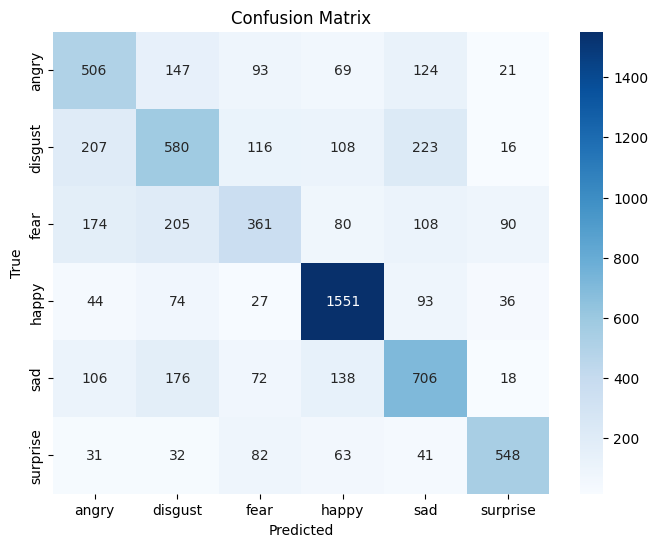

In [45]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels and predictions
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# Class names — adjust to your dataset
class_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']  # 6 classes

# Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
